Intestine
Tissue unit centroids + GMM
Community centroids + GMM
Neighborhood centroids + GMM
Network graphs at tissue unit, community, neighborhood
Catplots of regions at each level
Normalized network graphs where edge is geometric mean probability (supplemental figure)


In [21]:
import MINGLE as mg
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import networkx as nx
import seaborn as sns
from matplotlib.cm import get_cmap
import numpy as np
import os
from scipy.spatial.distance import cdist

In [2]:
file_path = r"Z:\MINGLE\Data\Intestine\05_25_HuBMAP_tunit.csv"
cells = mg.pp.read_file(file_path)

C:\Users\annet\Documents\Projects\MINGLE-Annette\MINGLE_scverse\MINGLE\src\MINGLE\pp\preprocessing.py:34: DtypeWarning: Columns (62,63,70) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
c:\Users\annet\anaconda3\envs\annette_MINGLE\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [3]:
# Tissue level
centroids = mg.tl.centroid_Calculation(
            cells,
            cluster_col="Community",
            neighborhood_col="Tissue Unit",
        )


KeyboardInterrupt: 

In [ ]:
# Community level
centroids = mg.tl.centroid_Calculation(
            cells,
            cluster_col="Neigthborhood",
            neighborhood_col="Community",
        )


In [4]:
# Neighborhood level
centroids = mg.tl.centroid_Calculation(
            cells,
            cluster_col="Cell Type",
            neighborhood_col="Neighborhood",
        )

In [ ]:
# Tissue level
gmm_gpu = mg.tl.gpu_gmm_probability(
            cells,
            centroids,
            cluster_col="Community",
            neighborhood_col="Tissue Unit",
        )


In [ ]:
# Community level
gmm_gpu = mg.tl.gpu_gmm_probability(
            cells,
            centroids,
            cluster_col="Neigthborhood",
            neighborhood_col="Community",
        )


In [5]:
# Neighborhood level
gmm_gpu = mg.tl.gpu_gmm_probability(
            cells,
            centroids,
            cluster_col="Cell Type",
            neighborhood_col="Neighborhood",
        )

GPU Processing batch 1/126...
GPU Processing batch 2/126...
GPU Processing batch 3/126...
GPU Processing batch 4/126...
GPU Processing batch 5/126...
GPU Processing batch 6/126...
GPU Processing batch 7/126...
GPU Processing batch 8/126...
GPU Processing batch 9/126...
GPU Processing batch 10/126...
GPU Processing batch 11/126...
GPU Processing batch 12/126...
GPU Processing batch 13/126...
GPU Processing batch 14/126...
GPU Processing batch 15/126...
GPU Processing batch 16/126...
GPU Processing batch 17/126...
GPU Processing batch 18/126...
GPU Processing batch 19/126...
GPU Processing batch 20/126...
GPU Processing batch 21/126...
GPU Processing batch 22/126...
GPU Processing batch 23/126...
GPU Processing batch 24/126...
GPU Processing batch 25/126...
GPU Processing batch 26/126...
GPU Processing batch 27/126...
GPU Processing batch 28/126...
GPU Processing batch 29/126...
GPU Processing batch 30/126...
GPU Processing batch 31/126...
GPU Processing batch 32/126...
GPU Processing ba

In [ ]:
# Tissue level
gmm_cpu =  mg.tl.cpu_gmm_probability(
            cells,
            centroids,
            cluster_col="Community",
            neighborhood_col="Tissue Unit",
        )


In [ ]:
# Community level
gmm_cpu =  mg.tl.cpu_gmm_probability(
            cells,
            centroids,
            cluster_col="Neighborhood",
            neighborhood_col="Community",
        )


In [ ]:
# Neighborhood level
gmm_cpu =  mg.tl.cpu_gmm_probability(
            cells,
            centroids,
            cluster_col="Cell Type",
            neighborhood_col="Neighborhood",
        )

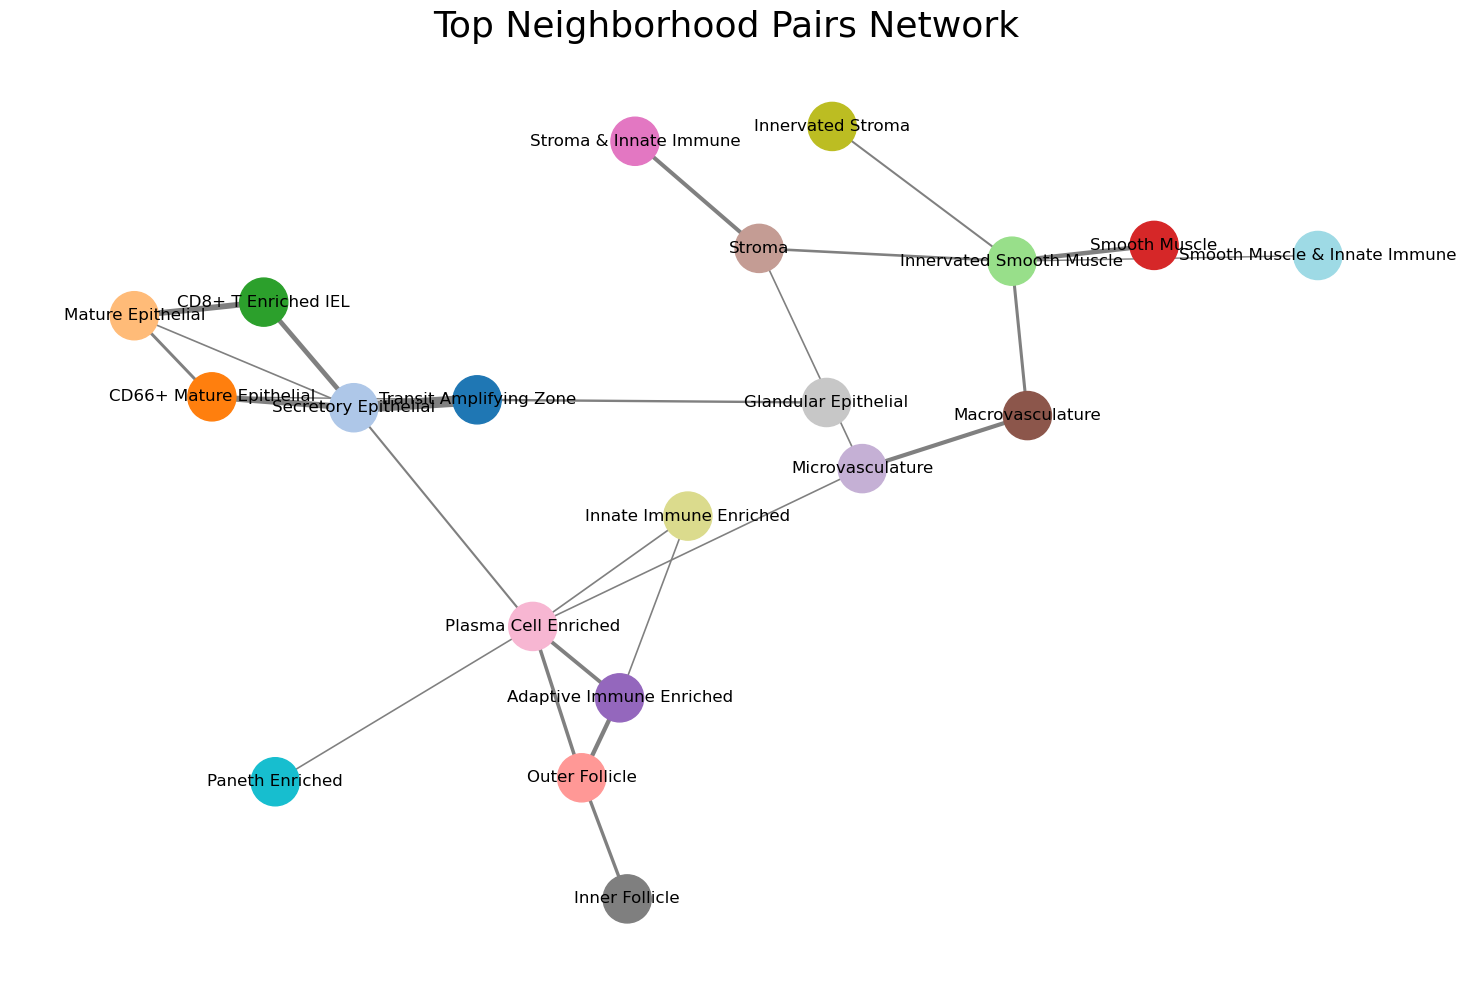

In [20]:

#Network graph at customized level
prob_cols = [
'Innate Immune Enriched', 'Outer Follicle', 'Plasma Cell Enriched',
'Transit Amplifying Zone', 'Adaptive Immune Enriched', 'Stroma',
'Paneth Enriched', 'Smooth Muscle & Innate Immune', 'Mature Epithelial',
'Microvasculature', 'CD8+ T Enriched IEL', 'Stroma & Innate Immune',
'Macrovasculature', 'Innervated Stroma', 'Secretory Epithelial',
'Innervated Smooth Muscle', 'Smooth Muscle', 'Glandular Epithelial',
'CD66+ Mature Epithelial', 'Inner Follicle'
]
#
G, top_pairs = mg.tl.build_neighborhood_pair_graph(
    cells,
    prob_cols,
    threshold=0.25,
    region_key="unique_region",
    top_n=25,
)
mg.tl.plot_neighborhood_pair_graph(cells)

In [17]:
## to use the palette later

import json

with open(r'Z:\MINGLE\Code\neighborhood_color_palette.json', 'r') as f:
    color_palette = json.load(f)

Plotting 'B010_Ileum': 39839 points


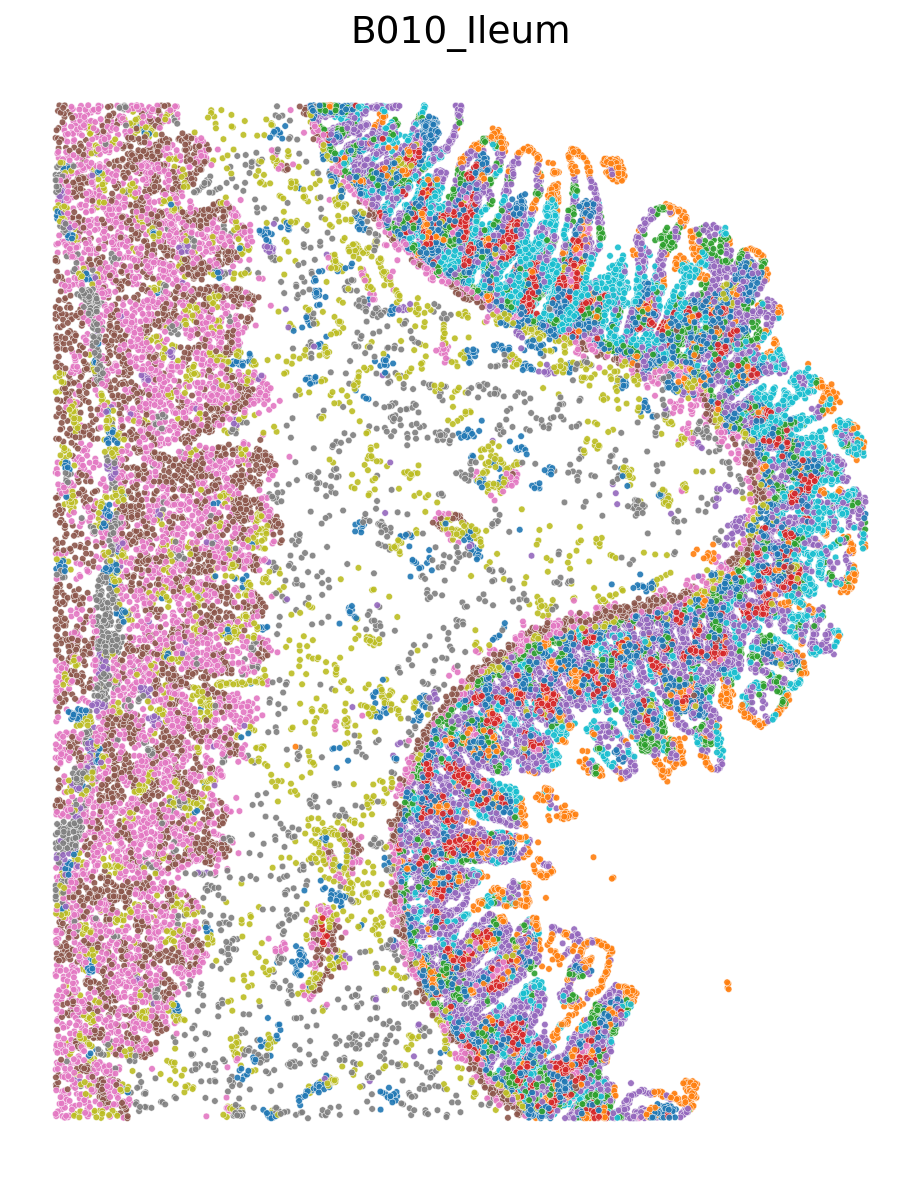

In [29]:

def catplot2(cells, hue, exp='Exp', X='X', Y='Y', invert_y=False, size=10,
             legend=True, palette="bright", figsize=6, style='white',
             exps=None, axis='on', scatter_kws=None,
             title_fontsize=20, legend_title_fontsize=12,
             legend_fontsize=10, dpi=150):
    # ---- Accept DataFrame or AnnData-like ----
    if hasattr(cells, "obs"):
        df = cells.obs.copy()
    elif isinstance(cells, pd.DataFrame):
        df = cells.copy()
    else:
        raise TypeError("Input must be a pandas DataFrame or an AnnData-like object with .obs")

    # stringify columns (safer)
    df.columns = df.columns.astype(str)

    # ---- Basic checks ----
    for key in [X, Y, hue, exp]:
        if key not in df.columns:
            raise KeyError(f"Column '{key}' not found in data.")

    # ensure categorical hue
    df[hue] = df[hue].astype("category")

    if scatter_kws is None:
        scatter_kws = {}
    # use a clear default size; user-provided `size` is marker area in scatterplot (s)
    scatter_kws = {**{'s': size, 'alpha': 0.9}, **scatter_kws}

    # optional y-inversion (operate on copy to avoid mutating original)
    df_plot = df.copy()
    if invert_y:
        df_plot[Y] = -df_plot[Y]

    sns.set_style({'axes.facecolor': style})

    # choose experiment groups
    if exps is None:
        exps = list(df_plot[exp].unique())
    elif not isinstance(exps, (list, tuple, np.ndarray)):
        exps = [exps]

    figures = []
    for name in exps:
        data_sub = df_plot[df_plot[exp] == name]
        # diagnostic: how many points (remove if noisy)
        print(f"Plotting '{name}': {data_sub.shape[0]} points")

        fig, ax = plt.subplots(figsize=(figsize, figsize), dpi=dpi)

        # draw points but avoid seaborn's built-in legend to keep it outside
        sns.scatterplot(
            x=X, y=Y, hue=hue, data=data_sub, ax=ax,
            palette=palette, legend=False, **scatter_kws
        )

        ax.set_title(str(name), fontsize=title_fontsize)
        if axis == 'off':
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_xlabel(''); ax.set_ylabel('')
            sns.despine(ax=ax, left=True, bottom=True)

        # Create an external legend from the artists (handles/labels)
        if legend:
            handles, labels = ax.get_legend_handles_labels()
            if len(handles) > 0:
                # Place legend outside the plot on the right
                legend_obj = ax.legend(
                    handles=handles, labels=labels, title=hue,
                    fontsize=legend_fontsize, title_fontsize=legend_title_fontsize,
                    loc='center left', bbox_to_anchor=(1.02, 0.5),
                    frameon=True, markerscale=2
                )
                # optionally style legend background/transparency
                legend_obj.get_frame().set_alpha(0.9)

        # Leave space on the right for the legend
        plt.tight_layout(rect=(0, 0, 0.78, 1.0))
        plt.show()

        figures.append((fig, ax))

    return figures


def adata_catplot(cells, region='B010_Ileum', x_key='x', y_key='y',
                  neigh_key='Neighborhood', region_key='unique_region',
                  palette=None):
    if hasattr(cells, "obs"):
        adata = cells
    elif isinstance(cells, pd.DataFrame):
        # allow passing in a pre-built DataFrame (will be used directly below)
        adata = None
    else:
        raise TypeError("`cells` must be an AnnData-like object or a pandas DataFrame")

    # If `cells` was an AnnData, subset by region first and then create a DataFrame
    if adata is not None:
        adata_reg = adata[adata.obs[region_key] == region]
        assigned_neighborhoods = adata_reg.obs[neigh_key].astype(str)
        # assigned_probabilities: safe access (if column exists)
        try:
            assigned_probabilities = adata_reg.obs.apply(
                lambda row: row[row[neigh_key]] if row[neigh_key] in row.index else np.nan, axis=1
            )
        except Exception:
            assigned_probabilities = pd.Series(index=adata_reg.obs_names, data=np.nan)

        visualization_df = pd.DataFrame({
            'x': adata_reg.obs[x_key],
            'y': adata_reg.obs[y_key],
            'Assigned Neighborhood': assigned_neighborhoods,
            'Assigned Probability': assigned_probabilities,
            region_key: adata_reg.obs[region_key]
        }, index=adata_reg.obs_names)
    else:
        # user passed a DataFrame as `cells` (assume it's already the visualization_df-like)
        visualization_df = cells.copy()

    plt.rcParams["legend.markerscale"] = 15

    figs = catplot2(
        visualization_df,
        X='x', Y='y', exp=region_key,
        hue='Assigned Neighborhood', axis='off', invert_y=False,
        size=10, figsize=8, legend=True,
        legend_title_fontsize=18, legend_fontsize=12, title_fontsize=18,
        palette=palette if palette is not None else "tab10", dpi=150
    )
    return figs

figs = adata_catplot(cells)   # or adata_catplot(cells, palette='tab10')




C:\Users\annet\AppData\Local\Temp\ipykernel_14020\2962599649.py:142: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab20")


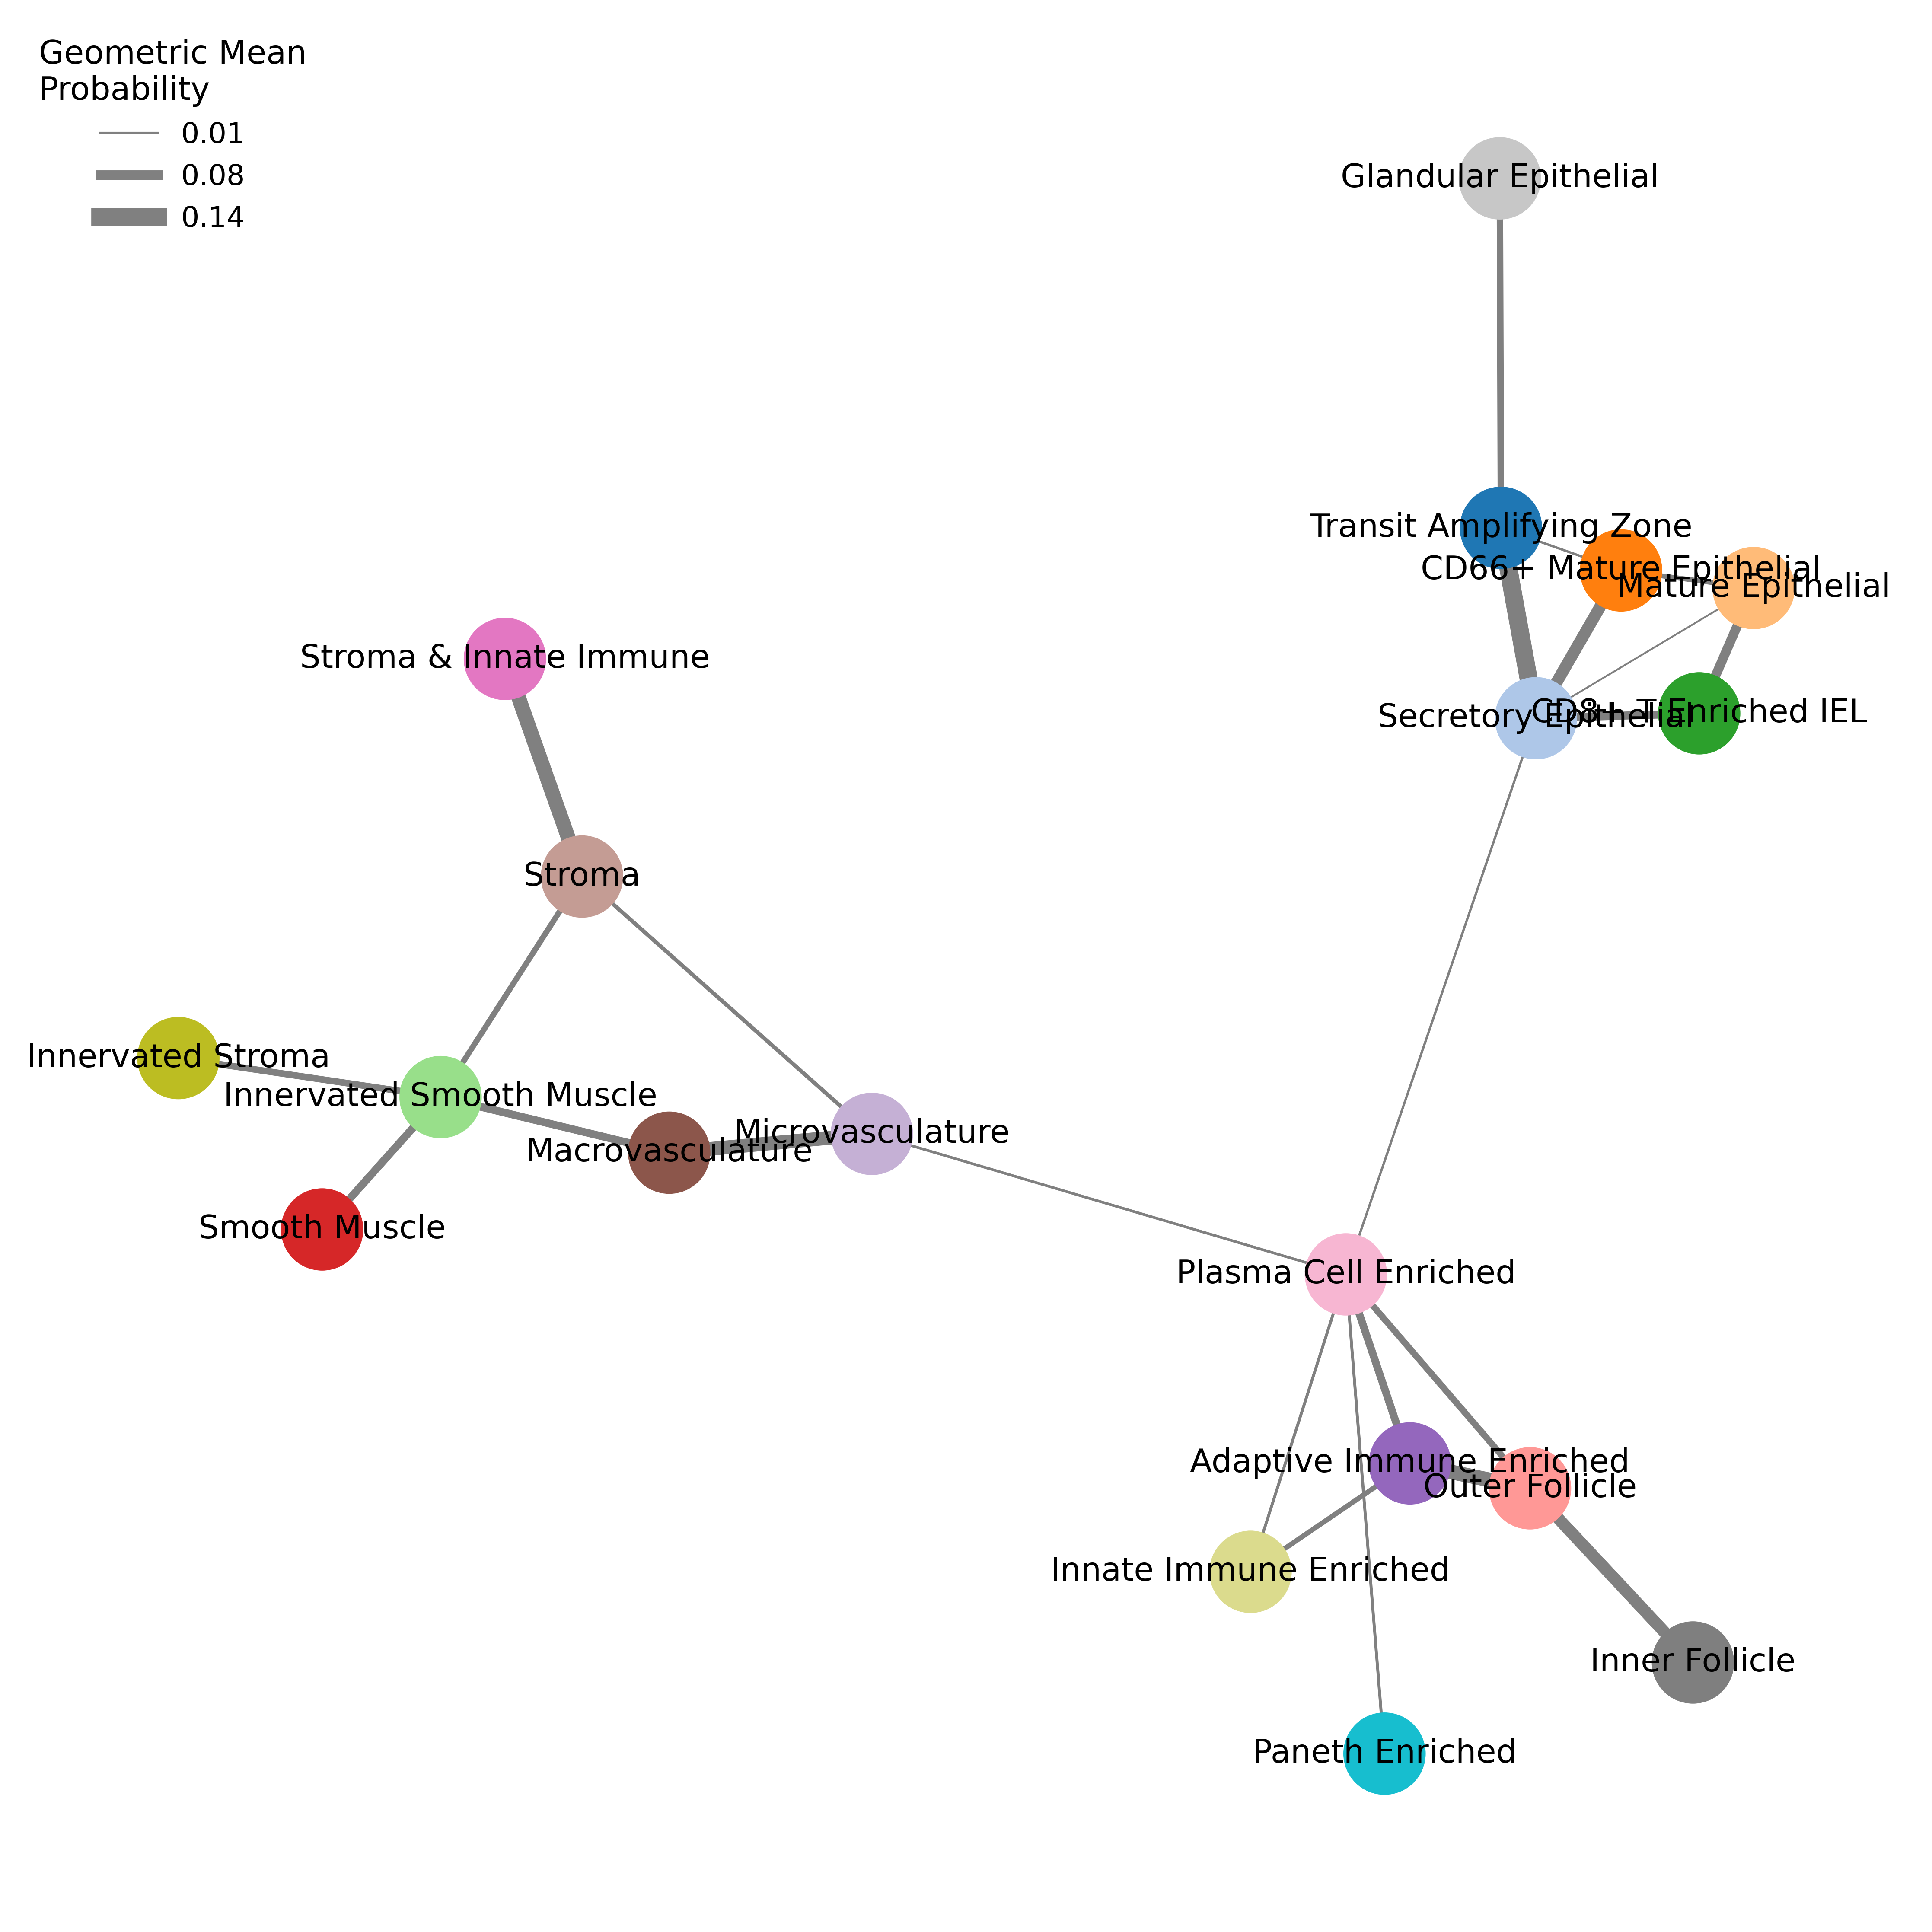

Edge summary (top shown):
                                                 edge  count  \
0      Transit Amplifying Zone & Secretory Epithelial  32318   
21                    Stroma & Stroma & Innate Immune  10671   
13          Outer Follicle & Adaptive Immune Enriched  11594   
18                Microvasculature & Macrovasculature  11106   
15                    Outer Follicle & Inner Follicle   8569   
3      Secretory Epithelial & CD66+ Mature Epithelial  17158   
8             Mature Epithelial & CD8+ T Enriched IEL  16238   
4          Secretory Epithelial & CD8+ T Enriched IEL  12946   
10        Innervated Smooth Muscle & Macrovasculature   7784   
9            Innervated Smooth Muscle & Smooth Muscle  12110   
16    Adaptive Immune Enriched & Plasma Cell Enriched  10141   
12       Innervated Smooth Muscle & Innervated Stroma   4621   
1      Transit Amplifying Zone & Glandular Epithelial   5727   
14              Outer Follicle & Plasma Cell Enriched   9219   
11            

In [42]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.cm import get_cmap

# ----------------- USER SETTINGS -----------------
prob_cols = [
    'Innate Immune Enriched', 'Outer Follicle', 'Plasma Cell Enriched',
    'Transit Amplifying Zone', 'Adaptive Immune Enriched', 'Stroma',
    'Paneth Enriched', 'Smooth Muscle & Innate Immune', 'Mature Epithelial',
    'Microvasculature', 'CD8+ T Enriched IEL', 'Stroma & Innate Immune',
    'Macrovasculature', 'Innervated Stroma', 'Secretory Epithelial',
    'Innervated Smooth Muscle', 'Smooth Muscle', 'Glandular Epithelial',
    'CD66+ Mature Epithelial', 'Inner Follicle'
]
region_key = "unique_region"
threshold = 0.25
top_n = 24

figsize = (15, 15)
dpi = 300
node_size = 2000
min_width_vis = 1.0
max_width_vis = 10.0
_eps = 1e-12
spring_k = 2
spring_seed = 28
# ------------------------------------------------

# ---- sanity checks ----
if not hasattr(cells, "obs"):
    raise TypeError("`cells` must be an AnnData-like object with .obs")

missing = [c for c in prob_cols + [region_key] if c not in cells.obs.columns]
if missing:
    raise KeyError(f"Missing columns in cells.obs: {missing}")

# -------------------------------
# 1) Build pair counts EXACTLY like your correct code:
#    - probs numeric
#    - count above threshold per cell
#    - keep cells where count==2
#    - record the two neighborhoods
#    - count pairs per region then sum
# -------------------------------
probs = cells.obs[prob_cols].apply(pd.to_numeric, errors="coerce")

counts = (probs > threshold).sum(axis=1)
mask = counts == 2

probs2 = probs.loc[mask]
regions = cells.obs.loc[mask, region_key]

above = probs2.gt(threshold)
pair_list = []
region_list = []

for idx in above.index:
    cols = list(above.columns[above.loc[idx].values])
    if len(cols) == 2:
        pair_list.append((cols[0], cols[1]))
        region_list.append(regions.loc[idx])

pairs_df = pd.DataFrame(pair_list, columns=["Neighborhood1", "Neighborhood2"])
pairs_df[region_key] = region_list

pair_counts = (
    pairs_df.groupby([region_key, "Neighborhood1", "Neighborhood2"])
    .size()
    .reset_index(name="count")
)

pair_counts_summed = (
    pair_counts.groupby(["Neighborhood1", "Neighborhood2"], as_index=False)["count"].sum()
)

pair_counts_summed = pair_counts_summed[pair_counts_summed["count"] > 0]
pair_counts_summed = pair_counts_summed.sort_values("count", ascending=False).reset_index(drop=True)
top_pairs = pair_counts_summed.head(top_n).copy()

# -------------------------------
# 2) Build graph (no string parsing)
# -------------------------------
G = nx.Graph()
for _, row in top_pairs.iterrows():
    n1 = row["Neighborhood1"]
    n2 = row["Neighborhood2"]
    G.add_edge(n1, n2, weight=int(row["count"]))

if G.number_of_edges() == 0:
    raise ValueError("Graph has no edges (no qualifying pairs). Try lowering threshold or increasing top_n.")

# -------------------------------
# 3) Totals per neighborhood (denominators) consistent with this analysis:
#    totals[n] = #cells where neighborhood n is above threshold (not raw celltype counts)
# -------------------------------
totals_series = (probs > threshold).sum(axis=0)
totals_dict = {str(k): int(v) for k, v in totals_series.items()}

# -------------------------------
# 4) Compute directional proportions + geometric mean enrichment per edge
# -------------------------------
edge_list = list(G.edges())
edge_counts = [G[u][v]["weight"] for u, v in edge_list]

enrichments = []
directional_props = []
for (u, v), cnt in zip(edge_list, edge_counts):
    total_u = float(totals_dict.get(u, 0.0))
    total_v = float(totals_dict.get(v, 0.0))

    prop_u = (cnt / total_u) if total_u > 0 else 0.0
    prop_v = (cnt / total_v) if total_v > 0 else 0.0

    prop_u = max(prop_u, _eps)
    prop_v = max(prop_v, _eps)

    enr = np.sqrt(prop_u * prop_v)  # geometric mean
    enrichments.append(enr)
    directional_props.append((prop_u, prop_v))

# -------------------------------
# 5) Map enrichment -> visual edge widths
# -------------------------------
e_min = float(min(enrichments)) if enrichments else 0.0
e_max = float(max(enrichments)) if enrichments else 1.0
if e_max == e_min:
    e_min = max(0.0, e_min - 1e-6)
    e_max = e_min + 1e-6

normalized_weights = [
    min_width_vis + (e - e_min) / (e_max - e_min) * (max_width_vis - min_width_vis)
    for e in enrichments
]

# -------------------------------
# 6) Layout + node colors
# -------------------------------
pos = nx.spring_layout(G, k=spring_k, seed=spring_seed)
cmap = get_cmap("tab20")
node_list = list(G.nodes())
node_colors = [cmap(i % 20) for i in range(len(node_list))]

# -------------------------------
# 7) Plot (style like your screenshot) + legend for geometric mean
# -------------------------------
plt.figure(figsize=figsize, dpi=dpi)

nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color=node_colors)
nx.draw_networkx_edges(G, pos, edge_color="gray", width=normalized_weights)
nx.draw_networkx_labels(G, pos, font_size=18)

# Legend for geometric mean probability -> same mapping as edges
legend_levels = [e_min, (e_min + e_max) / 2.0, e_max]

def to_width(e):
    return min_width_vis + (e - e_min) / (e_max - e_min) * (max_width_vis - min_width_vis)

legend_handles = [
    mlines.Line2D([], [], color="gray", linewidth=to_width(e), label=f"{e:.2f}")
    for e in legend_levels
]

ax = plt.gca()
ax.legend(handles=legend_handles,
          title="Geometric Mean\nProbability",
          fontsize=16,
          title_fontsize=18,
          loc="upper left",
          frameon=False)

plt.axis("off")
plt.tight_layout()
plt.show()

# -------------------------------
# 8) Summary table
# -------------------------------
summary = []
for (u, v), cnt, (prop_u, prop_v), enr in zip(edge_list, edge_counts, directional_props, enrichments):
    summary.append({
        "edge": f"{u} & {v}",
        "count": cnt,
        f"prop_{u}_to_{v}": prop_u,
        f"prop_{v}_to_{u}": prop_v,
        "enrichment_geom_mean": enr
    })
summary_df = pd.DataFrame(summary).sort_values("enrichment_geom_mean", ascending=False)

print("Edge summary (top shown):")
print(summary_df.head(20))